In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv(r"C:\Users\admin\Downloads\winequality-red.csv")   # change filename/sep if needed
 
print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())

Shape: (1599, 12)

Head:
    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8      

In [4]:
print("Rows before cleaning:", df.shape[0])
 
# Handle nulls (fill numeric nulls with median, if any)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
 
# IQR outlier removal on all feature columns (excluding target)
feature_cols = [c for c in df.columns if c != "quality"]
 
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1
 
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
 
mask = ~((df[feature_cols] < lower_bound) | (df[feature_cols] > upper_bound)).any(axis=1)
df = df[mask].reset_index(drop=True)
 
print("Rows after cleaning:", df.shape[0])

Rows before cleaning: 1599
Rows after cleaning: 1194


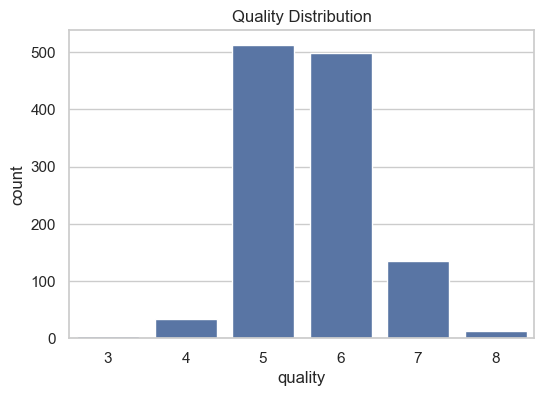

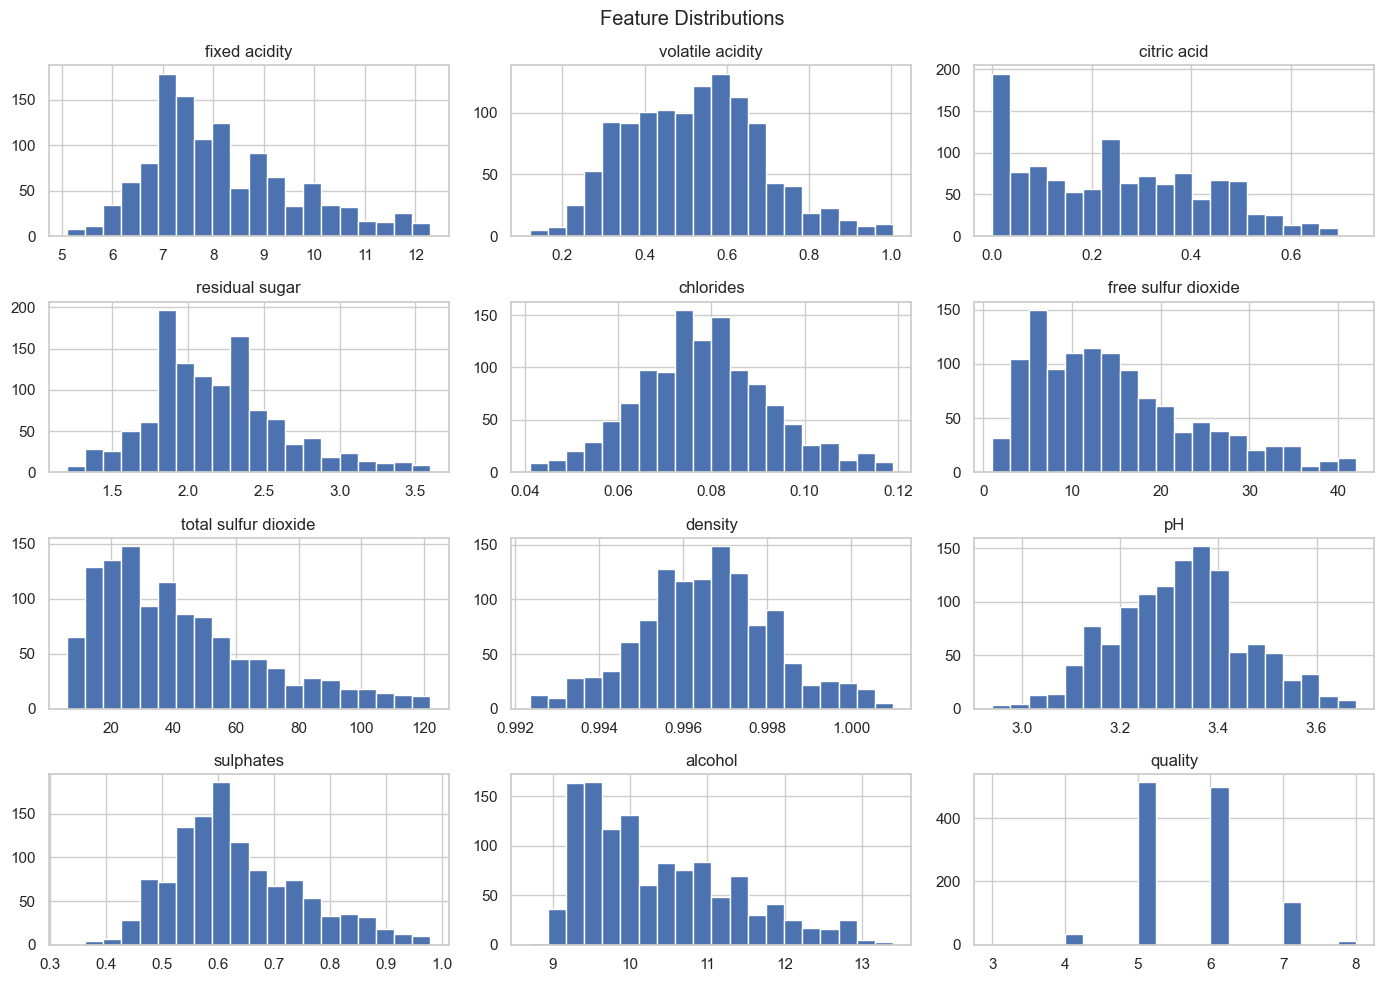

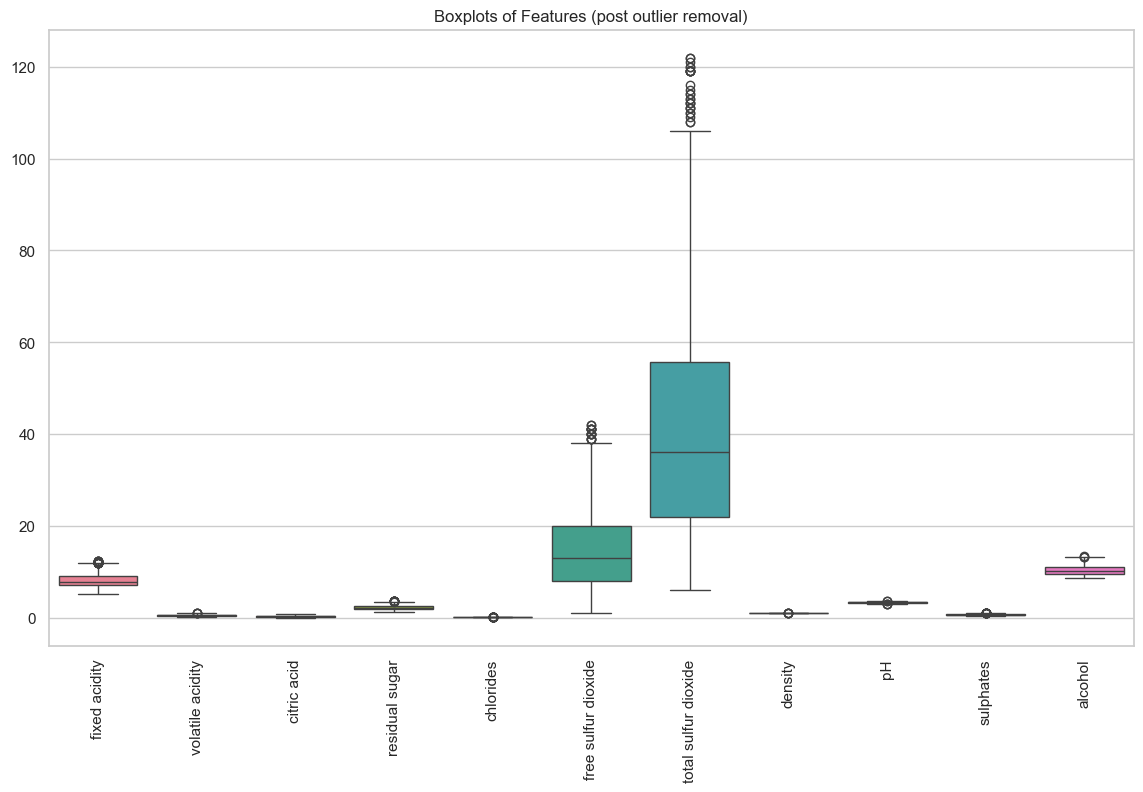

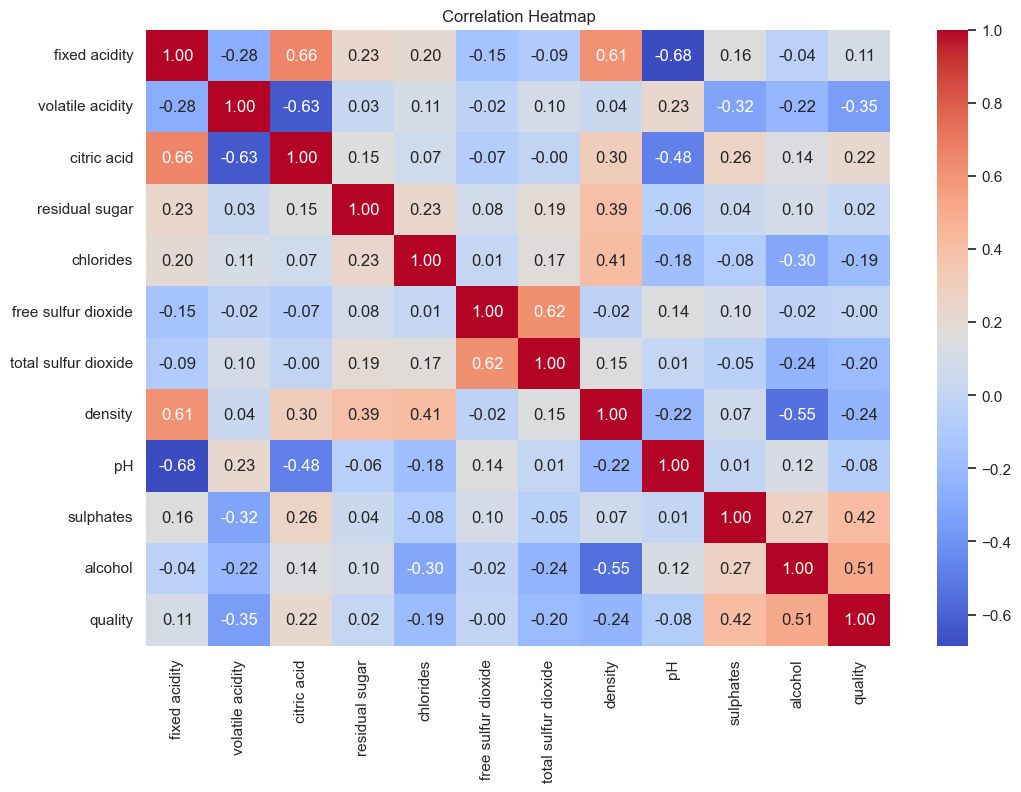

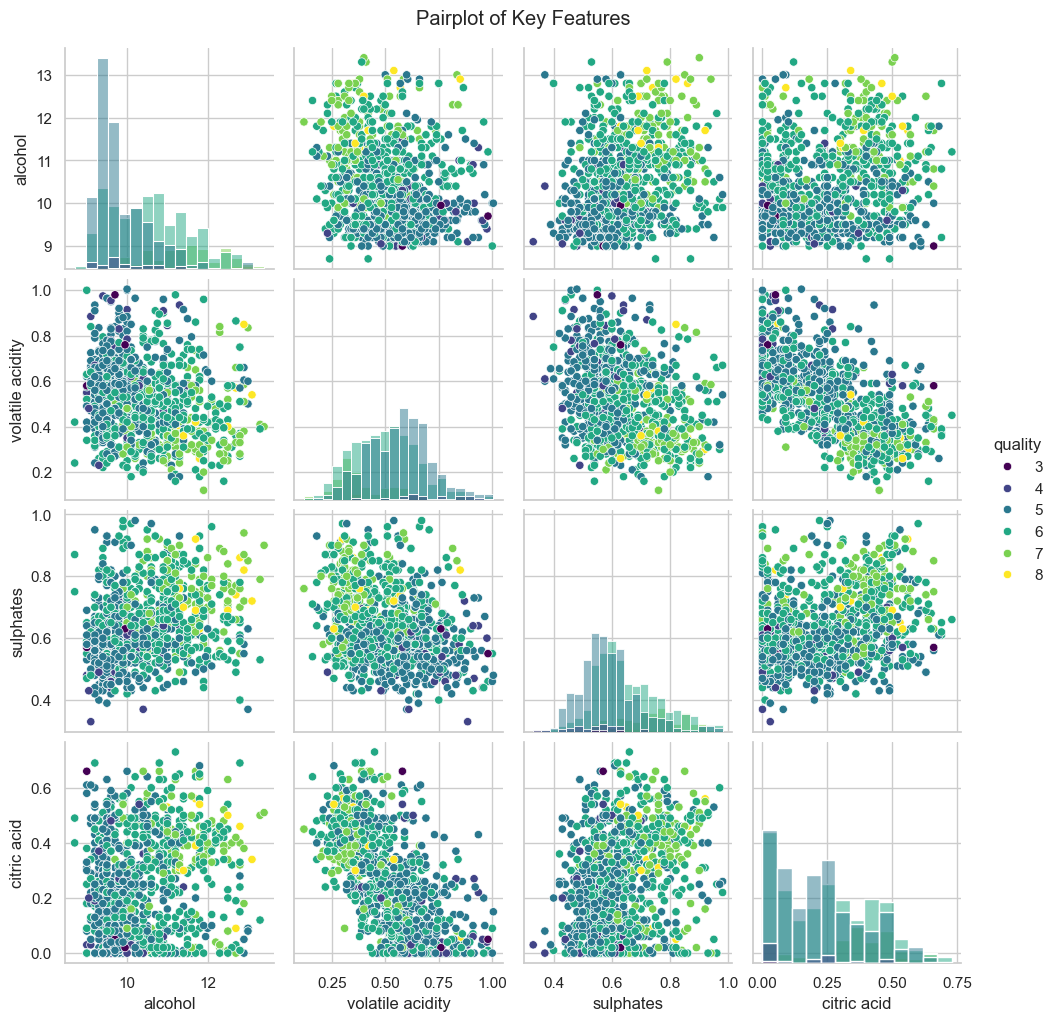

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="quality", data=df)
plt.title("Quality Distribution")
plt.show()
 
# Histograms
df.hist(figsize=(14,10), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()
 
# Boxplots
plt.figure(figsize=(14,8))
sns.boxplot(data=df[feature_cols])
plt.xticks(rotation=90)
plt.title("Boxplots of Features (post outlier removal)")
plt.show()
 
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
 
# Pairplot on a few key features
sns.pairplot(df[["alcohol", "volatile acidity", "sulphates", "citric acid", "quality"]],
             hue="quality", palette="viridis", diag_kind="hist")
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()



In [16]:

# %% Cell 5: Train-test split + feature scaling
X = df.drop("quality", axis=1)
y = df["quality"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
print("X_train:", X_train.shape, "X_test:", X_test.shape)
 

X_train: (955, 11) X_test: (239, 11)


In [17]:
results = {}
trained_models = {}

In [18]:
model_lr = LogisticRegression(max_iter=2000)
model_lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [19]:
trained_models["Logistic Regression"] = model_lr

===== Logistic Regression =====
Accuracy: 0.6067
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         7
           5       0.63      0.76      0.69       103
           6       0.58      0.57      0.57       100
           7       0.59      0.37      0.45        27
           8       0.00      0.00      0.00         2

    accuracy                           0.61       239
   macro avg       0.36      0.34      0.34       239
weighted avg       0.58      0.61      0.59       239



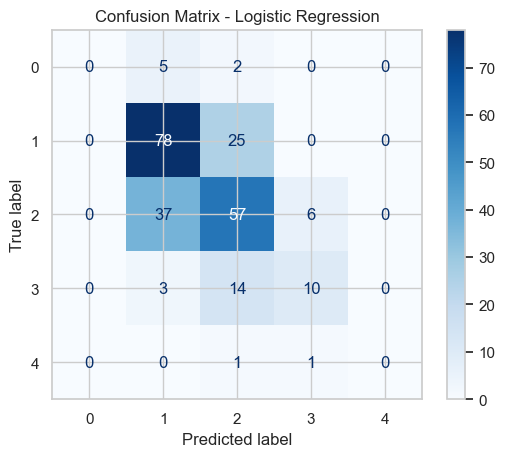

In [20]:
y_pred = model_lr.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
results["Logistic Regression"] = acc

print("===== Logistic Regression =====")
print("Accuracy:", round(acc, 4))
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [21]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_scaled, y_train)
trained_models["Decision Tree"] = model_dt

===== Decision Tree =====
Accuracy: 0.6276
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         7
           5       0.72      0.69      0.71       103
           6       0.65      0.62      0.63       100
           7       0.50      0.63      0.56        27
           8       0.00      0.00      0.00         2

    accuracy                           0.63       239
   macro avg       0.31      0.32      0.32       239
weighted avg       0.64      0.63      0.63       239



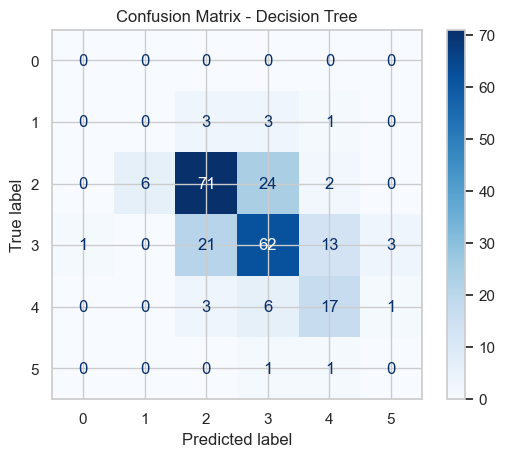

In [22]:
y_pred = model_dt.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
results["Decision Tree"] = acc

print("===== Decision Tree =====")
print("Accuracy:", round(acc, 4))
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [23]:
model_rf = RandomForestClassifier(random_state=42, n_estimators=200)
model_rf.fit(X_train_scaled, y_train)
trained_models["Random Forest"] = model_rf

===== Random Forest =====
Accuracy: 0.7155
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         7
           5       0.73      0.81      0.77       103
           6       0.70      0.73      0.72       100
           7       0.68      0.56      0.61        27
           8       0.00      0.00      0.00         2

    accuracy                           0.72       239
   macro avg       0.42      0.42      0.42       239
weighted avg       0.69      0.72      0.70       239



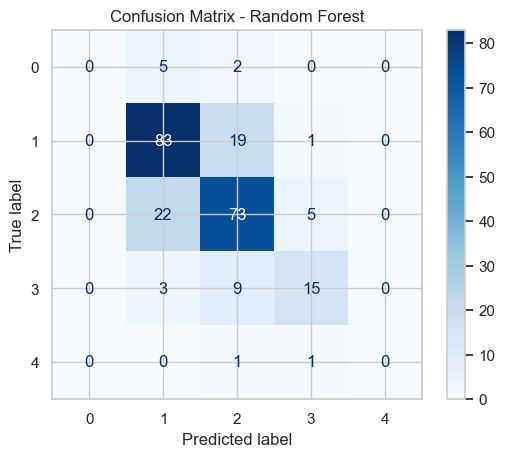

In [24]:
y_pred = model_rf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
results["Random Forest"] = acc

print("===== Random Forest =====")
print("Accuracy:", round(acc, 4))
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [25]:
model_gb = GradientBoostingClassifier(random_state=42)
model_gb.fit(X_train_scaled, y_train)
trained_models["Gradient Boosting"] = model_gb

===== Gradient Boosting =====
Accuracy: 0.6653
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         7
           5       0.70      0.80      0.75       103
           6       0.65      0.62      0.63       100
           7       0.62      0.56      0.59        27
           8       0.00      0.00      0.00         2

    accuracy                           0.67       239
   macro avg       0.33      0.33      0.33       239
weighted avg       0.64      0.67      0.65       239



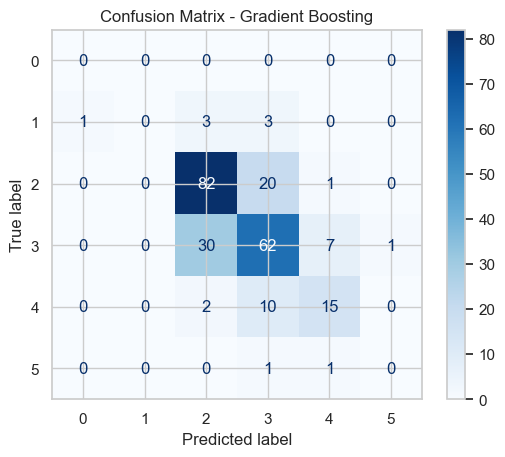

In [26]:
y_pred = model_gb.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
results["Gradient Boosting"] = acc

print("===== Gradient Boosting =====")
print("Accuracy:", round(acc, 4))
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

In [27]:
model_svm = SVC(probability=True)
model_svm.fit(X_train_scaled, y_train)
trained_models["SVM"] = model_svm

===== SVM =====
Accuracy: 0.6234
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         7
           5       0.65      0.80      0.72       103
           6       0.60      0.57      0.58       100
           7       0.56      0.37      0.44        27
           8       0.00      0.00      0.00         2

    accuracy                           0.62       239
   macro avg       0.36      0.35      0.35       239
weighted avg       0.59      0.62      0.60       239



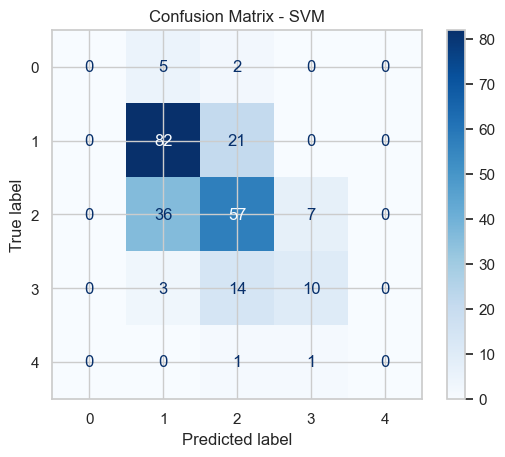

In [28]:
y_pred = model_svm.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
results["SVM"] = acc

print("===== SVM =====")
print("Accuracy:", round(acc, 4))
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()

In [29]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_scaled, y_train)
trained_models["KNN"] = model_knn

===== KNN =====
Accuracy: 0.5983
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         7
           5       0.67      0.75      0.71       103
           6       0.57      0.58      0.58       100
           7       0.38      0.30      0.33        27
           8       0.00      0.00      0.00         2

    accuracy                           0.60       239
   macro avg       0.32      0.32      0.32       239
weighted avg       0.57      0.60      0.58       239



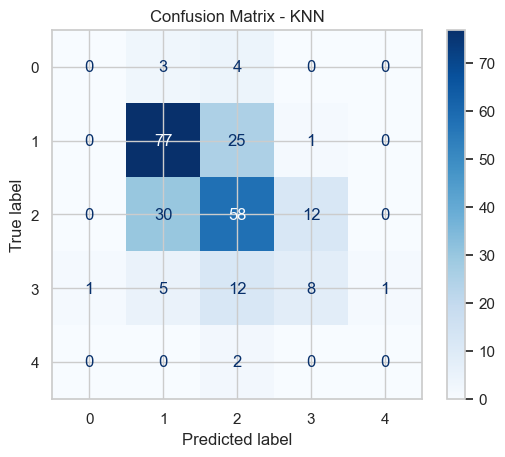

In [30]:
y_pred = model_knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
results["KNN"] = acc

print("===== KNN =====")
print("Accuracy:", round(acc, 4))
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - KNN")
plt.show()

In [31]:
model_nb = GaussianNB()
model_nb.fit(X_train_scaled, y_train)
trained_models["Naive Bayes"] = model_nb

===== Naive Bayes =====
Accuracy: 0.5732
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         7
           5       0.62      0.72      0.67       103
           6       0.60      0.46      0.52       100
           7       0.44      0.63      0.52        27
           8       0.00      0.00      0.00         2

    accuracy                           0.57       239
   macro avg       0.28      0.30      0.28       239
weighted avg       0.57      0.57      0.56       239



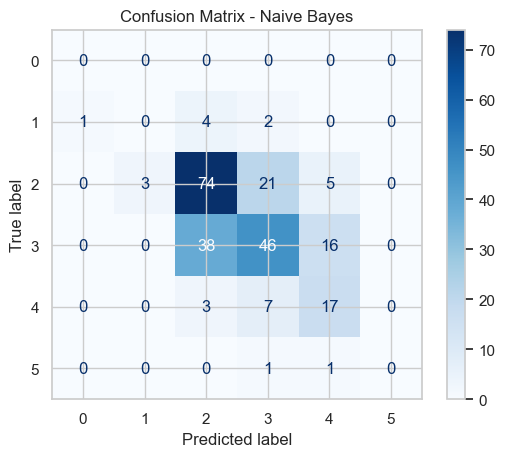

In [32]:
y_pred = model_nb.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
results["Naive Bayes"] = acc

print("===== Naive Bayes =====")
print("Accuracy:", round(acc, 4))
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

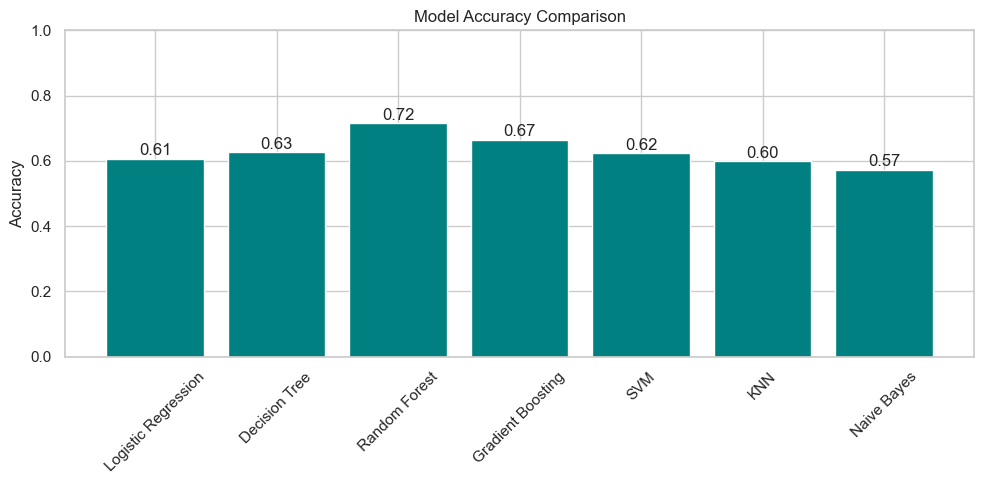


Best model: Random Forest with accuracy: 0.7155


In [33]:
# Cell 6.8: Final Comparison - Bar Graph + Best Model Selection
plt.figure(figsize=(10,5))
plt.bar(results.keys(), results.values(), color="teal")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylim(0, 1)
for i, (name, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha="center")
plt.tight_layout()
plt.show()

best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]
print("\nBest model:", best_model_name, "with accuracy:", round(results[best_model_name], 4))